In [2]:
import numpy as np
import matplotlib.pyplot as plt

# About the $w_n(\gamma)$ function

In the paper, we select $w_n(\gamma)=\alpha_n \gamma^{-(n+1)}$ as a candidate function to compute the integral over a rejection cost range of values, which derivates in the ECUAS$_n$ metric. Here, $\alpha_n\triangleq (n+1)u_M^{-(n+1)}$ where $u_M$ is the value that maximizes the uncertainty measurement $u_{\tilde C}(\mathbf{q})$ for all $\mathbf{q}\in\mathbb{S}_K$ and for a fixed cost function $\tilde C$. The value $K$ corresponds to the number of classes of the selective classifier.

The following shows a plot of $w_n(\gamma)$ for the case in which $\tilde C$ is the 0-1 cost. This implies that $u_M=1-\frac{1}{K}$ and that the integration range $[0,u_M]$.

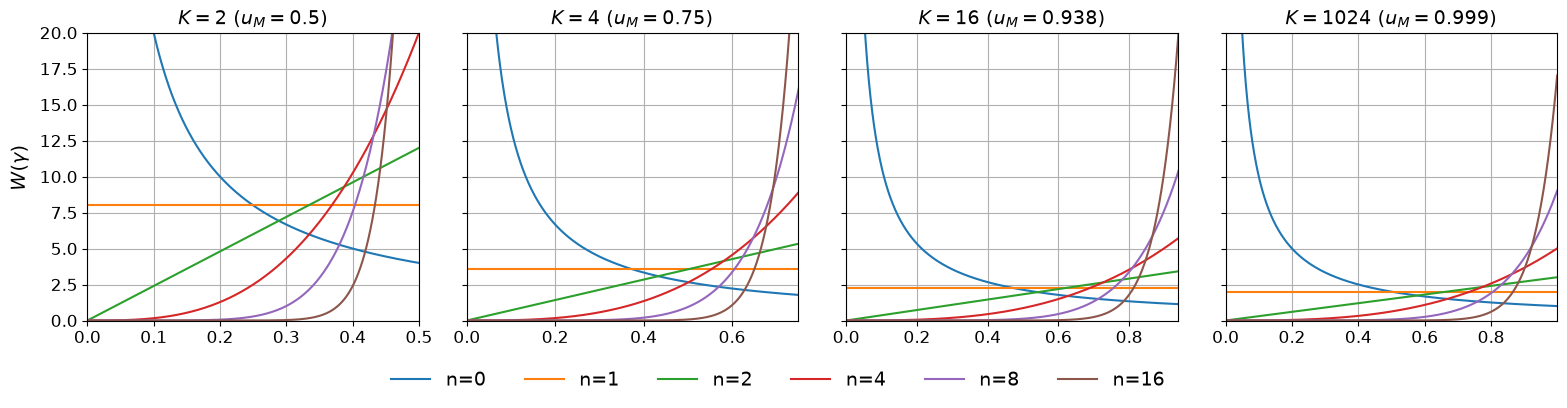

In [ ]:
def plot_W(ns, Ks):

    num_points = 1000
    gamma = np.linspace(0.001, 0.999, num_points)

    # Plot $W(\gamma) = \alpha_n \gamma^{n-1}$
    fig, ax = plt.subplots(1, len(Ks), figsize=(16, 4), sharey=True)
    legend_handles = None
    legend_labels = None

    for k, K in enumerate(Ks):
        u_M = (1 - 1/K)
        for n in ns:
            alpha_n = (n + 1) / (u_M ** (n + 1))
            W = alpha_n * np.power(gamma, n - 1)
            line, = ax[k].plot(gamma, W, label=f'n={n}')

        if legend_handles is None:
            legend_handles, legend_labels = ax[k].get_legend_handles_labels()

        ax[k].set_ylim([0, 20])
        ax[k].set_xlim([0, u_M])
        ax[k].set_title(r'$K={}$ $(u_M={})$'.format(K, np.round(u_M, 3)), fontsize=14)
        ax[k].grid(True)
        ax[k].tick_params(axis='both', labelsize=12)

    fig.suptitle(r'')
    fig.supylabel(r'$W(\gamma)$', fontsize=14)
    fig.legend(legend_handles, legend_labels, fontsize=14, loc='lower center', ncol=len(ns), frameon=False, bbox_to_anchor=(0.5, -0.1))
    fig.tight_layout(pad=1.5)

    plt.show()

ns = [0, 1, 2, 4, 8, 16]
Ks = [2, 4, 16, 1024]
plot_W(ns, Ks)
